Training samples: 25000
Testing samples: 25000
Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_3 (Embedding)     (None, 100, 128)          1280000   
                                                                 
 simple_rnn_6 (SimpleRNN)    (None, 100, 64)           12352     
                                                                 
 simple_rnn_7 (SimpleRNN)    (None, 64)                8256      
                                                                 
 dense_6 (Dense)             (None, 64)                4160      
                                                                 
 dropout_3 (Dropout)         (None, 64)                0         
                                                                 
 dense_7 (Dense)             (None, 1)                 65        
                                                                 
Total p

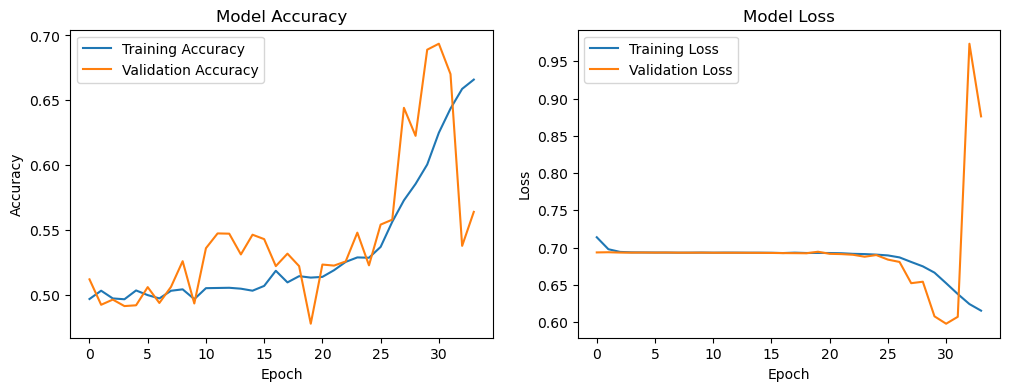


--- Final Evaluation ---
782/782 [==============================] - 6s 7ms/step - loss: 0.6047 - accuracy: 0.6858
Test Accuracy: 68.58000159263611
Test Loss: 0.6046802997589111
782/782 [==============================] - 6s 7ms/step


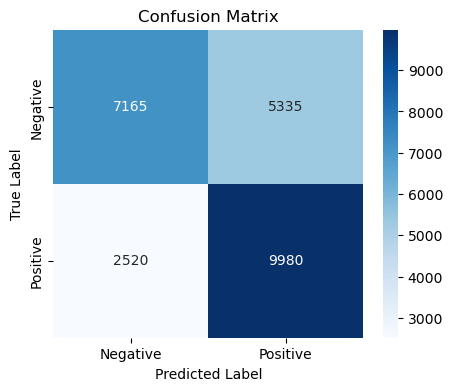


F1 Score: 0.7175984181197196

Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.57      0.65     12500
           1       0.65      0.80      0.72     12500

    accuracy                           0.69     25000
   macro avg       0.70      0.69      0.68     25000
weighted avg       0.70      0.69      0.68     25000



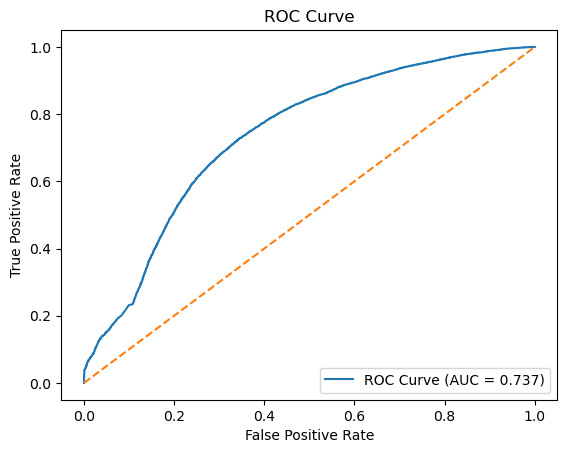

In [4]:
# ==========================================
# 1. Import Libraries
# ==========================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc, f1_score


# ==========================================
# 3. Data Loading
# ==========================================

vocab_size = 10000
max_length = 100
embedding_dim = 128

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

x_train = pad_sequences(x_train, maxlen=max_length, padding='post')
x_test = pad_sequences(x_test, maxlen=max_length, padding='post')

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

# ==========================================
# 4. Build Model (Forced GPU)
# ==========================================

with tf.device(device):

    model = keras.Sequential([

        keras.layers.Embedding(
            vocab_size,
            embedding_dim,
            input_length=max_length
        ),

        keras.layers.SimpleRNN(
            64,
            return_sequences=True,
            dropout=0.3,
            recurrent_dropout=0.3
        ),

        keras.layers.SimpleRNN(
            64,
            dropout=0.3
        ),

        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(0.4),

        keras.layers.Dense(1, activation='sigmoid')
    ])

model.summary()

# ==========================================
# 5. Compile Model
# ==========================================

optimizer = keras.optimizers.Adam(
    learning_rate=0.001,
    clipnorm=1.0
)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ==========================================
# 6. Callbacks
# ==========================================

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

lr_reduce = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=0.00001
)

# ==========================================
# 7. Train Model
# ==========================================

history = model.fit(
    x_train,
    y_train,
    epochs=80,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, lr_reduce]
)

# ==========================================
# 8. Accuracy & Loss Graphs
# ==========================================

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

# ==========================================
# 9. Model Evaluation
# ==========================================

print("\n--- Final Evaluation ---")

test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc*100)
print("Test Loss:", test_loss)

# ==========================================
# 10. Predictions
# ==========================================

y_pred_prob = model.predict(x_test)
y_pred = (y_pred_prob > 0.5).astype("int32")

# ==========================================
# 11. Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative','Positive'],
    yticklabels=['Negative','Positive']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

# ==========================================
# 12. F1 Score
# ==========================================

f1 = f1_score(y_test, y_pred)

print("\nF1 Score:", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ==========================================
# 13. ROC Curve
# ==========================================

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.3f)" % roc_auc)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.show()